# Setting Up the Environment

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

original_data = pd.read_csv('./dataset1.csv') # reading data from csv file
data = original_data.copy()  # making a copy so we don't modify the original dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   start_time                 907 non-null    object 
 1   bat_landing_to_food        907 non-null    float64
 2   habit                      866 non-null    object 
 3   rat_period_start           907 non-null    object 
 4   rat_period_end             907 non-null    object 
 5   seconds_after_rat_arrival  907 non-null    int64  
 6   risk                       907 non-null    int64  
 7   reward                     907 non-null    int64  
 8   month                      907 non-null    int64  
 9   sunset_time                907 non-null    object 
 10  hours_after_sunset         907 non-null    float64
 11  season                     907 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 85.2+ KB


### Checking for any null value

In [ ]:
data.isna().sum()

start_time                    0
bat_landing_to_food           0
habit                        41
rat_period_start              0
rat_period_end                0
seconds_after_rat_arrival     0
risk                          0
reward                        0
month                         0
sunset_time                   0
hours_after_sunset            0
season                        0
dtype: int64

# Analysing Habit Column

In [42]:
data['habit'].isna().sum()  # calcualting the number of row that contains NaN value.
data['habit'].unique()  # analyzing the uniqueness of data in habit column
data['habit'].value_counts()


habit
fast                                                245
rat                                                 221
pick                                                139
bat                                                  30
bat_fight                                            26
                                                   ... 
bat_fight_and_rat                                     1
rat_and_rat                                           1
not_sure_rat                                          1
501.0,358.4,636.2,423.4; 476.0,103.0,634.0,206.0      1
rat_and_bat_and_pick                                  1
Name: count, Length: 81, dtype: int64

### Cleaning Junks from Habit Column
After analyzing habit column, we knew it contains junk data and some strings contains characters like 'rat_attack'. At this stage, we don't know how important habit column. So we will be replacing the junk data and NaN value with `Unknown` string.

In [49]:
def clean_habit(row):
    if pd.isna(row):    #checking if given value is null value or not
        return 'Unknown'
    val_check = str(row).strip()  # converting everything to strings
    
    if re.fullmatch(r'^[\d\.,;\s]+$', val_check): # checks if strings is made of digit, dots or character
        return 'Unknown'
    
    val = val_check.lower().replace('_', ' ')  # lower strings and replacing '_' with white space
    return re.sub(r'\s+', ' ', val).strip()

data.loc[:,'habit'] = data['habit'].map(clean_habit)  # assigning cleaned column to copied df


In [ ]:
data['habit'].value_counts() # checked how many time a value is repeated after cleaning the data
data['habit'].drop_duplicates().count()  # removing and counting only unique value, we got 64

np.int64(64)

### Grouping Single values in habit column
After cleaning the data, we again check the uniqueness of data and count their value. Our analysis shows true uniquness of data is 64 out of given dataset. So we dicided to group all the data that are represented only once. 

### Converting to datetime

In [3]:
cols = ['start_time', 'rat_period_start', 'rat_period_end', 'sunset_time'] #colmns that contain data in {date time} format.
data['Date'] = pd.to_datetime(data['start_time'], dayfirst=True).dt.date

def split_datetime_column(data, cols): 
    for col in cols: # looping through each columns
        data[col] = pd.to_datetime(data[col], dayfirst=True).dt.time # converting data in each row of the column to dtype time, removing date
    return data

new_data_with_date = split_datetime_column(data, cols)


### Checking for Duplicate

In [4]:
data.duplicated().sum()
data = data.drop_duplicates()

### Checking for Outlier

<Axes: ylabel='bat_landing_to_food'>

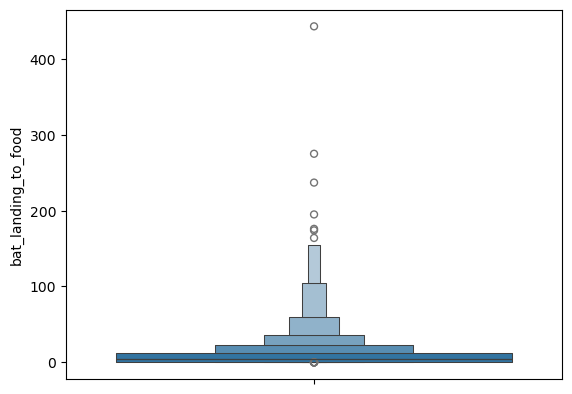

In [5]:
sns.boxenplot(y=data['bat_landing_to_food'])